<a href="https://colab.research.google.com/github/vorrjjard-2/bi_finalproj/blob/main/train_pred.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
import pandas as pd
import numpy as np
import xgboost as xgb

import sklearn

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score

In [26]:
from google.colab import drive
drive.mount('/content/drive')

ModuleNotFoundError: No module named 'google.colab'

In [27]:
cd drive/MyDrive

[WinError 3] The system cannot find the path specified: 'drive/MyDrive'
d:\Coding\Github-Repo\bi_finalproj


In [28]:
df = pd.read_csv('dataset_target.csv')

In [29]:
y = df.pop('target')
X = df

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

scaler = StandardScaler()

norm_cols = X.columns[X.nunique() > 2]
bin_cols = X.columns[X.nunique() <= 2]

X_train_norm = pd.DataFrame(scaler.fit_transform(X_train[norm_cols]), columns=norm_cols, index=X_train.index)
X_train = pd.concat([X_train_norm, X_train[bin_cols]], axis=1)

X_test_norm = pd.DataFrame(scaler.transform(X_test[norm_cols]), columns=norm_cols, index=X_test.index)
X_test = pd.concat([X_test_norm, X_test[bin_cols]], axis=1)

X_train = X_train.astype('float32')
X_test = X_train.astype('float32')

y_train = y_train.astype('long')
y_test = y_train.astype('long')


## XGBOOST

In [30]:
model = xgb.XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.1)
model.fit(X_train, y_train)

preds = model.predict(X_test)

In [ ]:
tp, fp, fn, tn = confusion_matrix(y_test, preds).ravel()

In [31]:
accuracy = (tp + tn) / (tp + tn + fp + fn)
recall = tp / (tp + fn)

print(f"Accuracy: {accuracy:.4f}")
print(f"Recall: {recall:.4f}")

Accuracy: 0.9456
Recall: 0.9394


In [32]:

f1 = f1_score(y_test, preds)
print(f"F1 Score: {f1:.4f}")

F1 Score: 0.8013


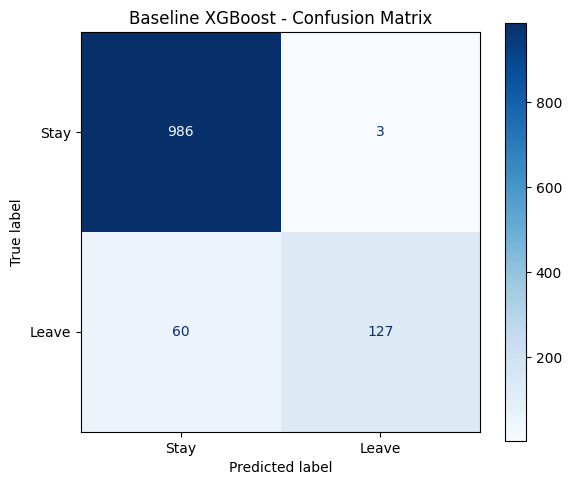

Saved: XGBoost_confusion_matrix.png


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Stay", "Leave"])
disp.plot(ax=ax, cmap='Blues')
ax.set_title("XGBoost - Confusion Matrix")
plt.tight_layout()
plt.savefig("XGBoost_confusion_matrix.png", dpi=150)
plt.show()
print("Saved: XGBoost_confusion_matrix.png")